In [27]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import os

In [28]:
curr_dir_path = os.getcwd()
main_dir_path = os.path.abspath(os.path.join(curr_dir_path, os.pardir))
data_dir_path = os.path.join(main_dir_path, 'data')
raw_data_dir_path = os.path.join(data_dir_path, 'raw_data')
processed_data_dir_path = os.path.join(data_dir_path, 'processed_data')
cw_dir_path = os.path.join(data_dir_path, 'cw')
emissions_data_dir_path = os.path.join(raw_data_dir_path, 'emissions_data')
iea_data_dir_path = os.path.join(raw_data_dir_path, 'IEA_climate_policy_data')

In [29]:
emissions_total_df = pd.read_csv(os.path.join(processed_data_dir_path, 'total_emissions_with_policies.csv'))
emissions_change_df = pd.read_csv(os.path.join(processed_data_dir_path, 'emissions_change_with_policies.csv'))

In [45]:
emissions_total_df

,iso3,year,country,policies_last_5_years,income_group,prev_year_emission,avg_emissions_prev_3_years,total_emissions
0,AFG,2001,Afghanistan,0.0,Low income,25.390391,25.390391,23.723115
1,AFG,2002,Afghanistan,0.0,Low income,23.723115,24.556753,26.383509
2,AFG,2003,Afghanistan,0.0,Low income,26.383509,25.165672,27.071538
3,AFG,2004,Afghanistan,0.0,Low income,27.071538,25.726054,27.128799
4,AFG,2005,Afghanistan,0.0,Low income,27.128799,26.861282,27.530896
...,...,...,...,...,...,...,...,...
4175,ZWE,2018,Zimbabwe,1.0,Lower middle income,45.410983,46.390136,47.509033
4176,ZWE,2019,Zimbabwe,0.0,Lower middle income,47.509033,46.277579,46.442562
4177,ZWE,2020,Zimbabwe,1.0,Lower middle income,46.442562,46.454193,44.576343
4178,ZWE,2021,Zimbabwe,1.0,Lower middle income,44.576343,46.175979,45.759664


In [31]:
emissions_change_df.head()

,iso3,year,country,policies_per_year,policies_last_5_years,income_group,avg_change_prev_3_years,prev_year_change,emissions_change
0,AFG,2002,Afghanistan,0,0.0,Low income,-0.067921,-0.067921,0.106289
1,AFG,2003,Afghanistan,0,0.0,Low income,0.019184,0.106289,0.025744
2,AFG,2004,Afghanistan,0,0.0,Low income,0.021371,0.025744,0.002113
3,AFG,2005,Afghanistan,0,0.0,Low income,0.044715,0.002113,0.014713
4,AFG,2006,Afghanistan,1,0.0,Low income,0.014190,0.014713,0.009749


## Cleaning

In [32]:
# Drop policies_per_year col in both dfs
emissions_total_df.drop(columns=['policies_per_year'], inplace=True)
emissions_change_df.drop(columns=['policies_per_year'], inplace=True)

In [33]:
# Check for missing values
missing_values_total = emissions_total_df.isnull().sum()
missing_values_change = emissions_change_df.isnull().sum()
print("Missing values in total emissions DataFrame:\n", missing_values_total)
print("Missing values in emissions change DataFrame:\n", missing_values_change)
# Check for duplicates
duplicates_total = emissions_total_df.duplicated().sum()
duplicates_change = emissions_change_df.duplicated().sum()
print("Duplicates in total emissions DataFrame:", duplicates_total)
print("Duplicates in emissions change DataFrame:", duplicates_change)

Missing values in total emissions DataFrame:
 iso3                            0
year                            0
country                         0
policies_last_5_years           0
income_group                    0
prev_year_emission            190
avg_emissions_prev_3_years    190
total_emissions                 0
dtype: int64
Missing values in emissions change DataFrame:
 iso3                       0
year                       0
country                    0
policies_last_5_years      0
income_group               0
avg_change_prev_3_years    0
prev_year_change           0
emissions_change           0
dtype: int64
Duplicates in total emissions DataFrame: 0
Duplicates in emissions change DataFrame: 0


In [34]:
# Drop null values in total emissions DataFrame
emissions_total_df.dropna(inplace=True)

# Reset index
emissions_total_df.reset_index(drop=True, inplace=True)

In [35]:
# # Add two interaction terms
# emissions_total_df['policy_intensity_vs_emission_level'] = emissions_total_df['policies_last_3_years'] * emissions_total_df['prev_year_emission']
# emissions_total_df['policy_trend_lag_interaction'] = emissions_total_df['policies_last_3_years'] * emissions_total_df['avg_emissions_prev_3_years']


In [36]:
# emissions_change_df['policy_intensity_vs_emission_level'] = emissions_change_df['policies_last_3_years'] * emissions_change_df['prev_year_change']
# emissions_change_df['policy_trend_lag_interaction'] = emissions_change_df['policies_last_3_years'] * emissions_change_df['avg_change_prev_3_years']

## EDA

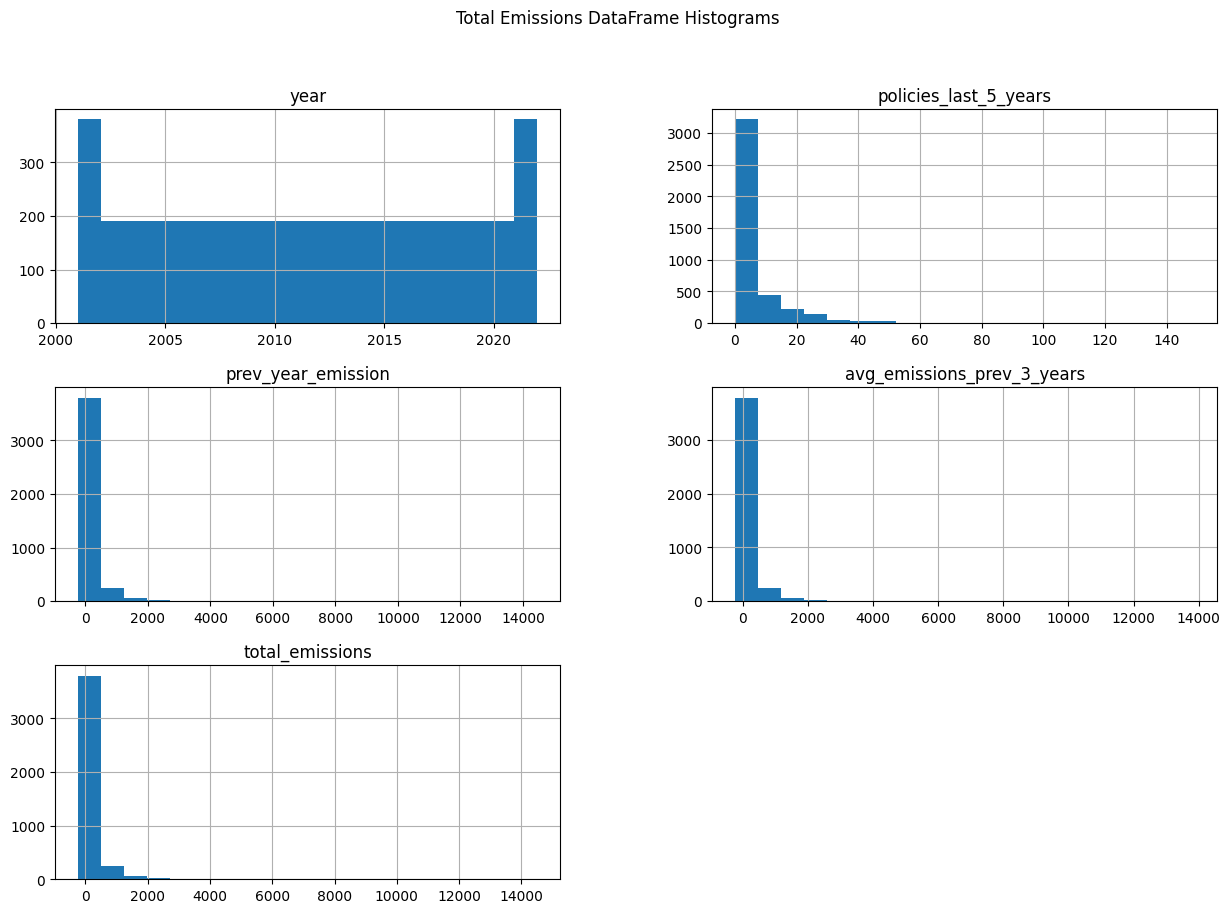

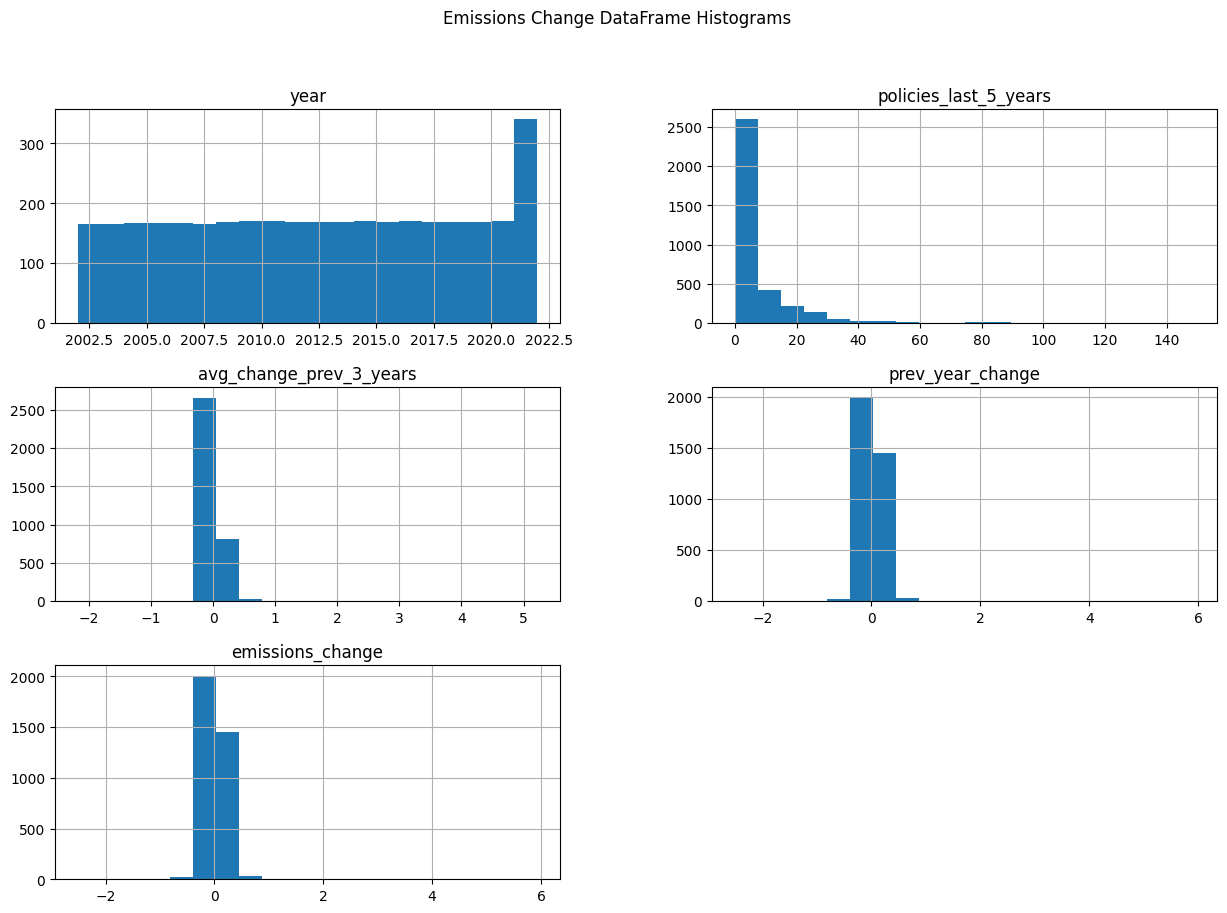

In [37]:
# Plot histograms of numeric columns
def plot_histograms(df, title):
    numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
    df[numeric_cols].hist(bins=20, figsize=(15, 10))
    plt.suptitle(title)
    plt.show()

plot_histograms(emissions_total_df, 'Total Emissions DataFrame Histograms')
plot_histograms(emissions_change_df, 'Emissions Change DataFrame Histograms')

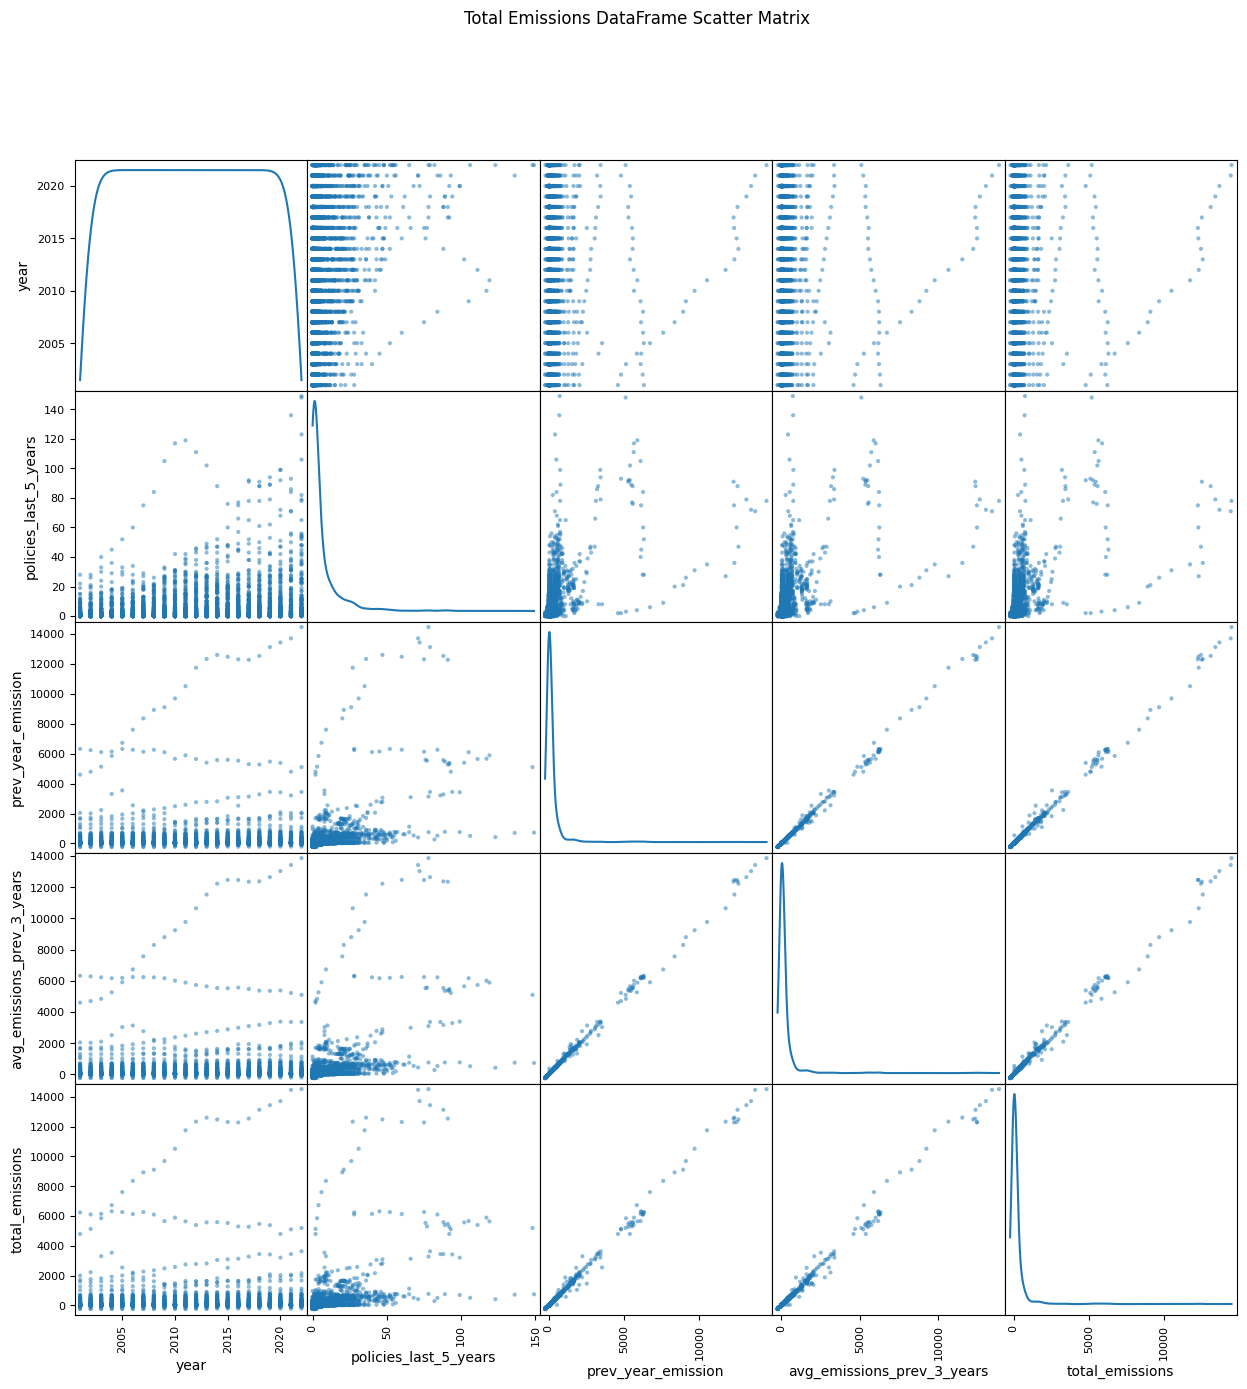

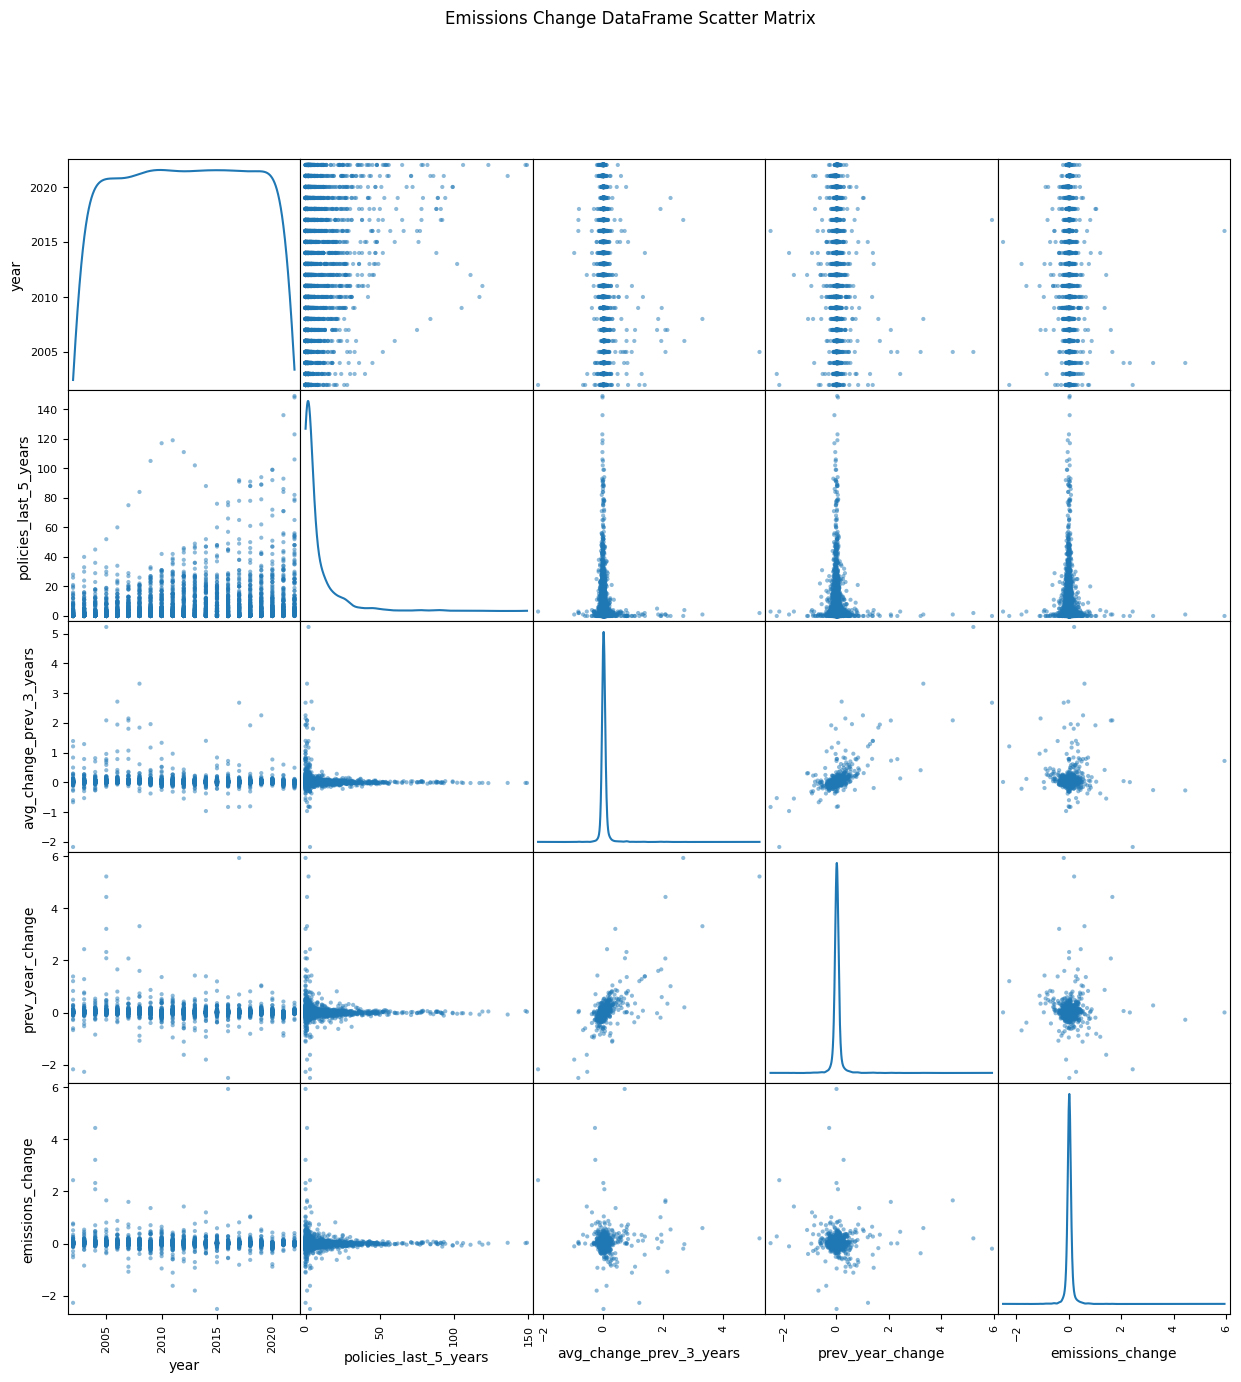

In [38]:
# Plot scatter plots of numeric columns
def plot_scatter_matrix(df, title):
    numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
    pd.plotting.scatter_matrix(df[numeric_cols], figsize=(15, 15), diagonal='kde')
    plt.suptitle(title)
    plt.show()
plot_scatter_matrix(emissions_total_df, 'Total Emissions DataFrame Scatter Matrix')
plot_scatter_matrix(emissions_change_df, 'Emissions Change DataFrame Scatter Matrix')


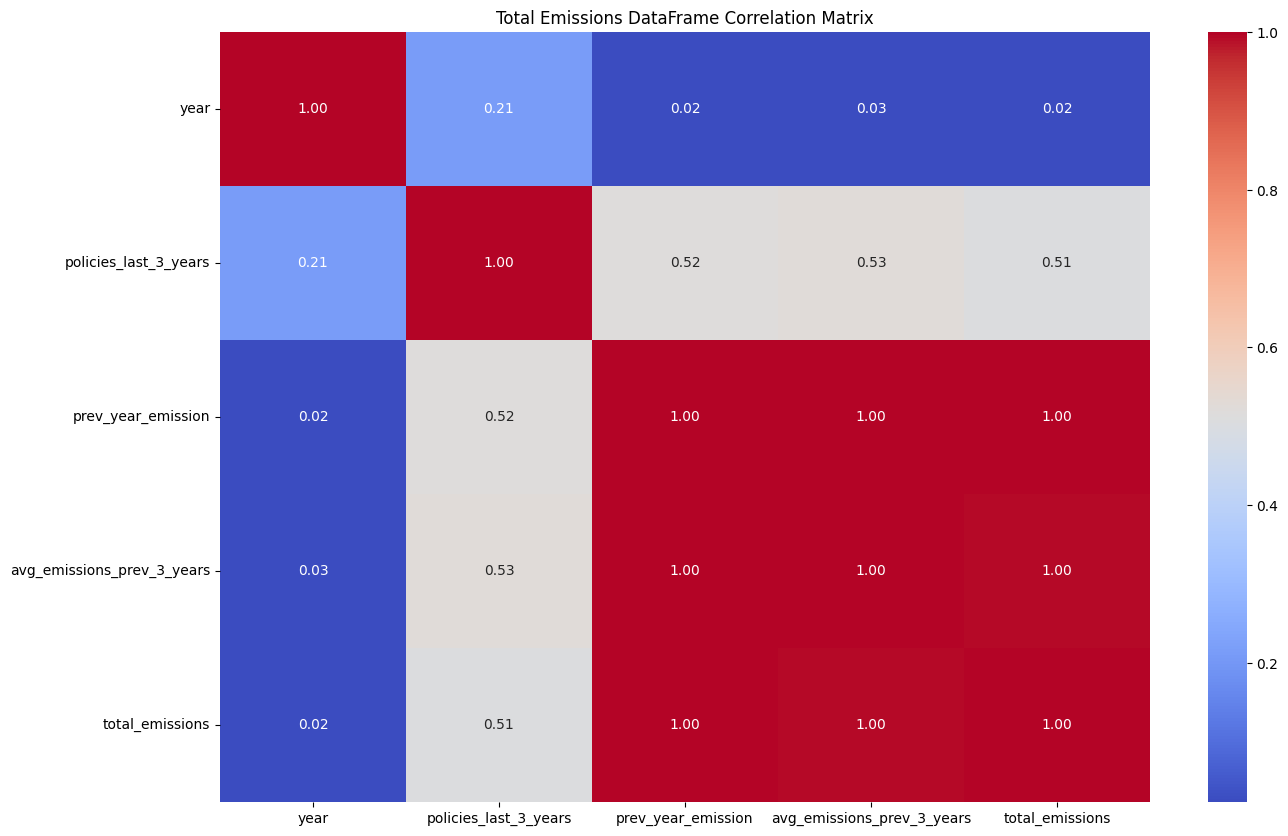

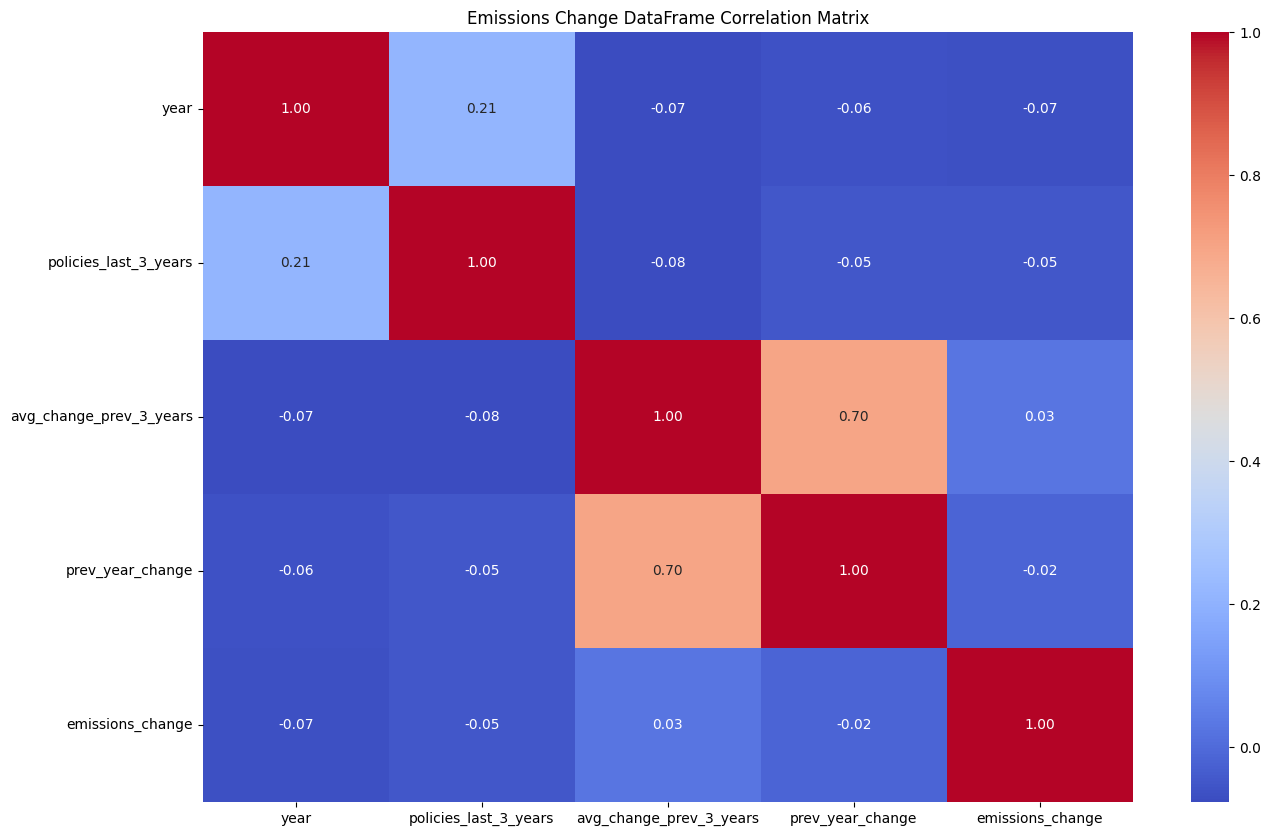

In [18]:
import seaborn as sns

# Plot correlation matrix of only numeric columns using a heatmap
def plot_correlation_matrix(df, title):
    numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
    corr = df[numeric_cols].corr()
    plt.figure(figsize=(15, 10))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, xticklabels=corr.columns, yticklabels=corr.columns)
    plt.title(title)
    plt.show()

plot_correlation_matrix(emissions_total_df, 'Total Emissions DataFrame Correlation Matrix')
plot_correlation_matrix(emissions_change_df, 'Emissions Change DataFrame Correlation Matrix')


In [43]:
# Get the countries with the highest and lowest emissions averages
def get_highest_lowest_emissions(df, col):
    highest_emissions = df.groupby('country')[col].mean().nlargest(10)
    lowest_emissions = df.groupby('country')[col].mean().nsmallest(10)
    return highest_emissions, lowest_emissions
highest_total_emissions, lowest_total_emissions = get_highest_lowest_emissions(emissions_total_df, 'total_emissions')

print(highest_total_emissions)
print(lowest_total_emissions)

country
People's Republic of China    10553.663607
United States                  5697.816474
India                          2687.885792
Brazil                         1904.644669
Russian Federation             1681.681290
Indonesia                      1462.269916
Japan                          1259.893804
Germany                         905.049163
Islamic Republic of Iran        819.447855
Canada                          728.584465
Name: total_emissions, dtype: float64
country
Central African Republic   -217.497933
Mali                       -181.692136
Namibia                     -96.504962
Gabon                       -88.218009
Cameroon                    -40.090080
Liberia                     -16.848773
Belize                       -7.572627
Vanuatu                      -6.336221
Niger                        -5.828922
Bhutan                       -5.517821
Name: total_emissions, dtype: float64


In [44]:
# Get the countries with the highest and lowest policy counts
def get_highest_lowest_policies(df, col):
    highest_policies = df.groupby('country')[col].mean().nlargest(10)
    lowest_policies = df.groupby('country')[col].mean().nsmallest(10)
    return highest_policies, lowest_policies
highest_policy_count, lowest_policy_count = get_highest_lowest_policies(emissions_total_df, 'policies_last_5_years')

print(highest_policy_count)
print(lowest_policy_count)

country
United States                 82.363636
Canada                        48.909091
India                         42.363636
People's Republic of China    40.136364
Australia                     39.545455
United Kingdom                34.909091
Germany                       34.863636
Mexico                        29.727273
France                        26.681818
Spain                         26.409091
Name: policies_last_5_years, dtype: float64
country
Eritrea                                  0.045455
Palau                                    0.045455
Somalia                                  0.045455
Timor-Leste                              0.181818
Bermuda                                  0.227273
Cayman Islands                           0.227273
French Polynesia                         0.227273
Benin                                    0.272727
Bhutan                                   0.272727
Democratic People's Republic Of Korea    0.272727
Name: policies_last_5_years, dtype: floa

### **Step 0 – Define Objectives**

| Option | Goal | Target Variable |
|-------|------|-----------------|
| 1️⃣ Predict emissions | Predict the **total CO₂ emissions** in a future year | `total_emissions` |
| 2️⃣ Estimate effect of policies | Estimate the **impact of policies on the change in emissions** | `emissions_change = total_emissions - prev_year_emission` |



## Define Functions

In [19]:
def time_series_train_test_split(df, target, features, split_year=2018, income_subset=None):
    
    if income_subset:
        test = df[(df.income_group.isin(income_subset)) & (df['year'] > split_year)]
    else:
        test = df[df['year'] > split_year]
    
    train = df[df['year'] <= split_year]
    

    print(f"Train shape: {train.shape}")
    print(f"Test shape: {test.shape}")

    print(f'train / test split: {train.shape[0] / df.shape[0]} / {test.shape[0] / df.shape[0]}')

    X_train, y_train = train[features], train[target]
    X_test, y_test = test[features], test[target]

    return X_train, y_train, X_test, y_test


In [20]:

def simple_rf_regressor(X_train, y_train, X_test, y_test):
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    print("MAE:", mean_absolute_error(y_test, preds))
    print("R²:", r2_score(y_test, preds))

    # Scatter plot of actual vs predicted
    plt.scatter(y_test, preds)
    plt.xlabel('True Values')
    plt.ylabel('Predictions')
    plt.show()
    

    return model


In [21]:
def train_and_test_model(df, target, features, split_year=2017, income_subset=None):
    X_train, y_train, X_test, y_test = time_series_train_test_split(df, target, features, split_year, income_subset)
    model = simple_rf_regressor(X_train, y_train, X_test, y_test)
    importance = pd.Series(model.feature_importances_, index=features)
    print(importance.sort_values(ascending=False))
    importance.sort_values(ascending=False).plot(kind='barh')
    
    return model

## Train Models

### Prediction Model

Train shape: (3230, 9)
Test shape: (950, 9)
train / test split: 0.7727272727272727 / 0.22727272727272727
MAE: 18.470887898714953
R²: 0.9882552183560817


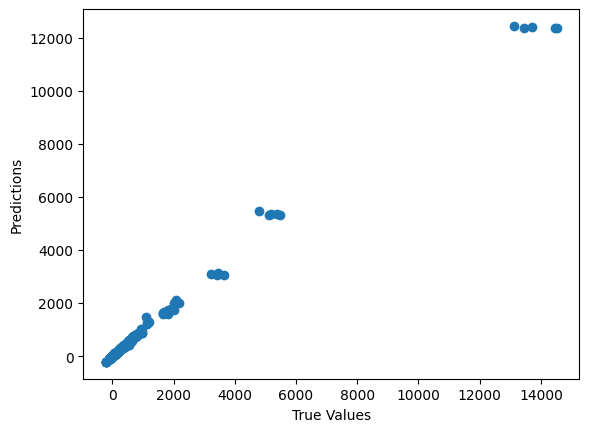

prev_year_emission                    0.560769
avg_emissions_prev_3_years            0.432721
year                                  0.002405
policy_intensity_vs_emission_level    0.001893
policy_trend_lag_interaction          0.001532
policies_last_3_years                 0.000681
dtype: float64


RandomForestRegressor(random_state=42)

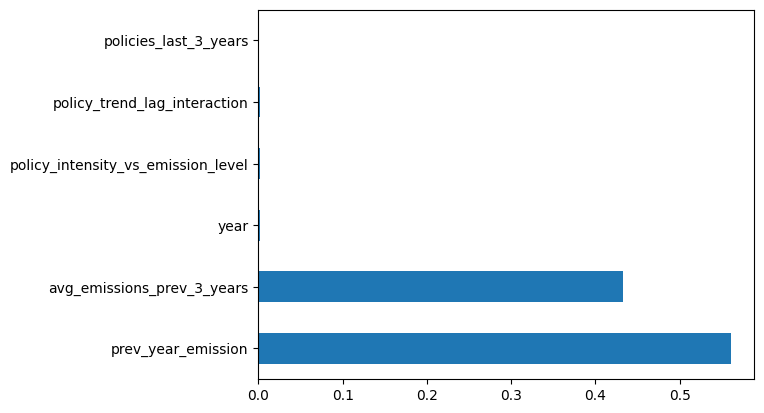

In [32]:
target = 'total_emissions'
features = emissions_total_df.drop(columns=['total_emissions', 'income_group', 'iso3']).columns
train_and_test_model(emissions_total_df, target, features)

In [33]:
emissions_total_df.income_group.unique()

array(['Low income', 'Lower middle income', 'Upper middle income',
       'High income'], dtype=object)

Train shape: (3230, 9)
Test shape: (125, 9)
train / test split: 0.7727272727272727 / 0.029904306220095694


MAE: 1.4737209001745735
R²: 0.9990369946641784


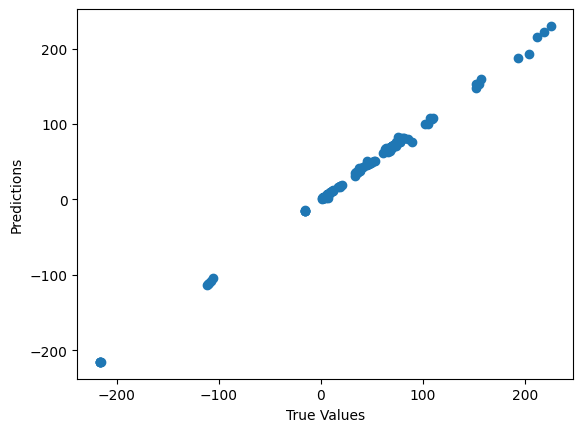

prev_year_emission                    0.560769
avg_emissions_prev_3_years            0.432721
year                                  0.002405
policy_intensity_vs_emission_level    0.001893
policy_trend_lag_interaction          0.001532
policies_last_3_years                 0.000681
dtype: float64


RandomForestRegressor(random_state=42)

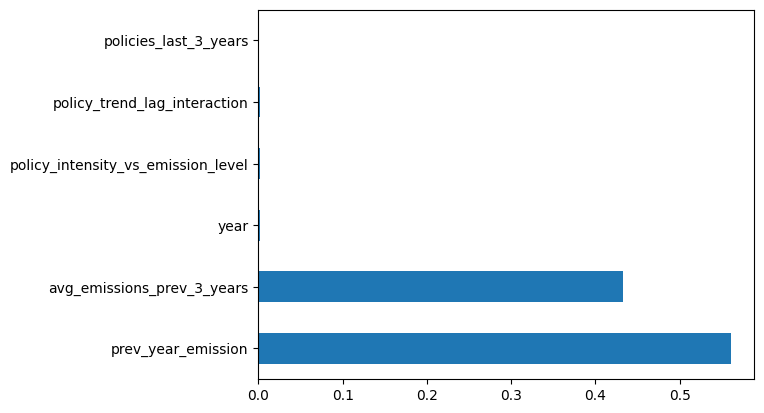

In [34]:
train_and_test_model(emissions_total_df, target, features, income_subset=['Low income'])

Train shape: (3230, 9)
Test shape: (265, 9)
train / test split: 0.7727272727272727 / 0.06339712918660287
MAE: 12.802501413223704
R²: 0.98797546380266


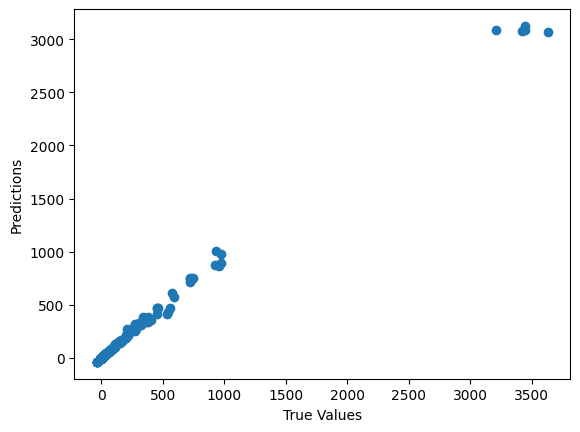

prev_year_emission                    0.560769
avg_emissions_prev_3_years            0.432721
year                                  0.002405
policy_intensity_vs_emission_level    0.001893
policy_trend_lag_interaction          0.001532
policies_last_3_years                 0.000681
dtype: float64


RandomForestRegressor(random_state=42)

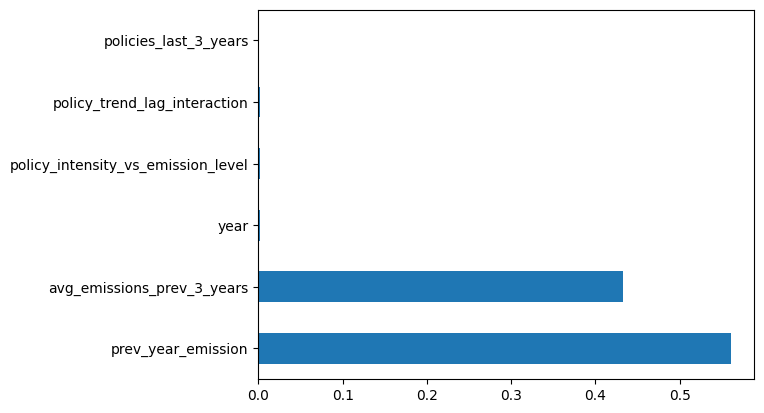

In [35]:
train_and_test_model(emissions_total_df, target, features, income_subset=['Lower middle income'])


Train shape: (3230, 9)
Test shape: (240, 9)
train / test split: 0.7727272727272727 / 0.05741626794258373
MAE: 41.088158836671134
R²: 0.987045833069964


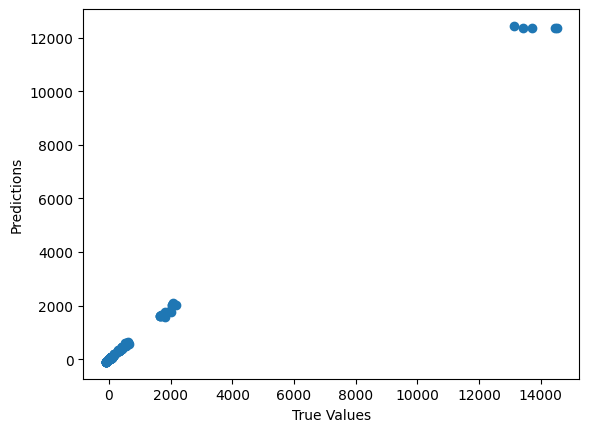

prev_year_emission                    0.560769
avg_emissions_prev_3_years            0.432721
year                                  0.002405
policy_intensity_vs_emission_level    0.001893
policy_trend_lag_interaction          0.001532
policies_last_3_years                 0.000681
dtype: float64


RandomForestRegressor(random_state=42)

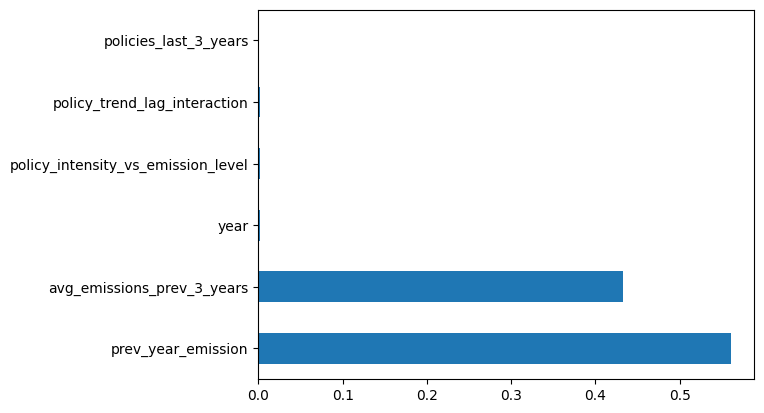

In [36]:
train_and_test_model(emissions_total_df, target, features, income_subset=['Upper middle income'])


Train shape: (3230, 9)
Test shape: (320, 9)
train / test split: 0.7727272727272727 / 0.07655502392344497
MAE: 12.841585612350087
R²: 0.9946362676163895


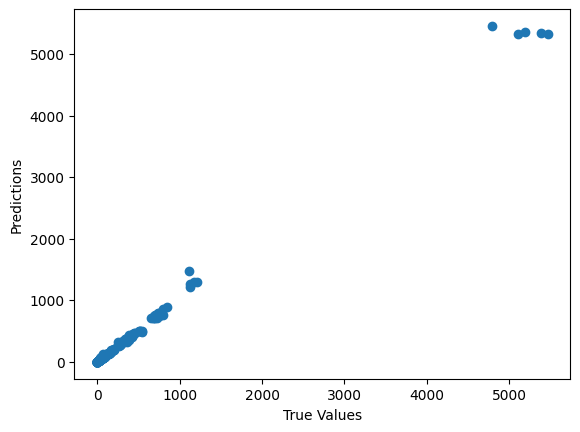

prev_year_emission                    0.560769
avg_emissions_prev_3_years            0.432721
year                                  0.002405
policy_intensity_vs_emission_level    0.001893
policy_trend_lag_interaction          0.001532
policies_last_3_years                 0.000681
dtype: float64


RandomForestRegressor(random_state=42)

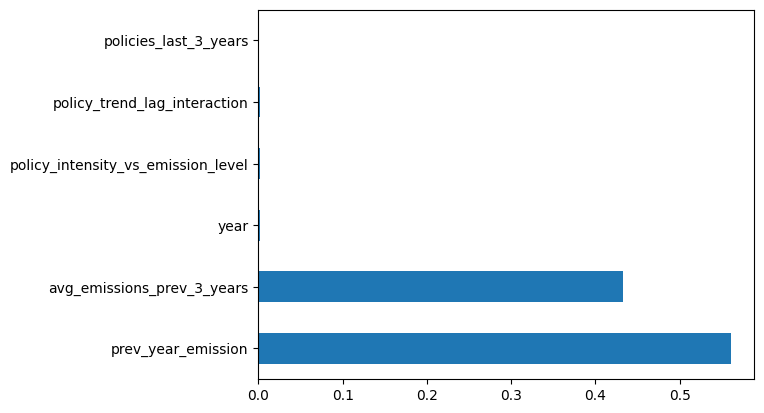

In [37]:
train_and_test_model(emissions_total_df, target, features, income_subset=['High income'])

### Estimate the effect of policies

Train shape: (2693, 9)
Test shape: (848, 9)
train / test split: 0.7605196272239481 / 0.23948037277605197
MAE: 0.05959136243195678
R²: -0.05774193627324831


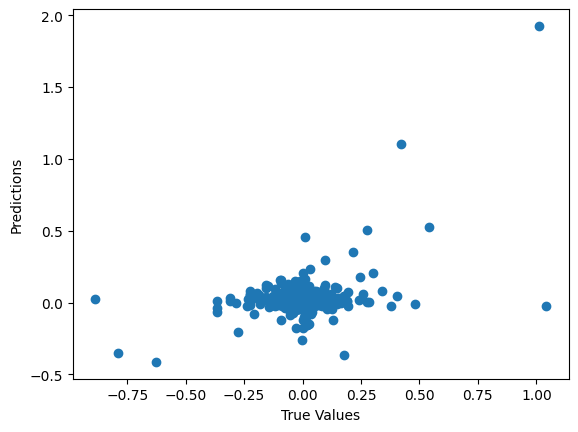

avg_change_prev_3_years               0.485517
prev_year_change                      0.253822
year                                  0.140575
policy_trend_lag_interaction          0.053566
policy_intensity_vs_emission_level    0.050388
policies_last_3_years                 0.016132
dtype: float64


RandomForestRegressor(random_state=42)

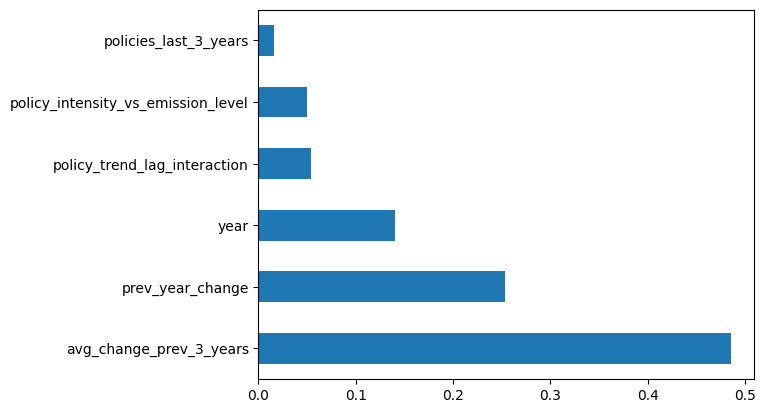

In [38]:
target = 'emissions_change'
features = emissions_change_df.drop(columns=['emissions_change', 'income_group', 'iso3']).columns

train_and_test_model(emissions_change_df, target, features)

Train shape: (2693, 9)
Test shape: (108, 9)
train / test split: 0.7605196272239481 / 0.030499858796950014
MAE: 0.045725707842056866
R²: -1.1611737427067355


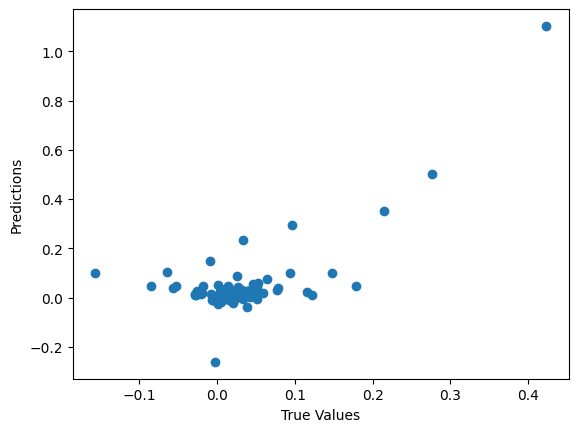

avg_change_prev_3_years               0.485517
prev_year_change                      0.253822
year                                  0.140575
policy_trend_lag_interaction          0.053566
policy_intensity_vs_emission_level    0.050388
policies_last_3_years                 0.016132
dtype: float64


RandomForestRegressor(random_state=42)

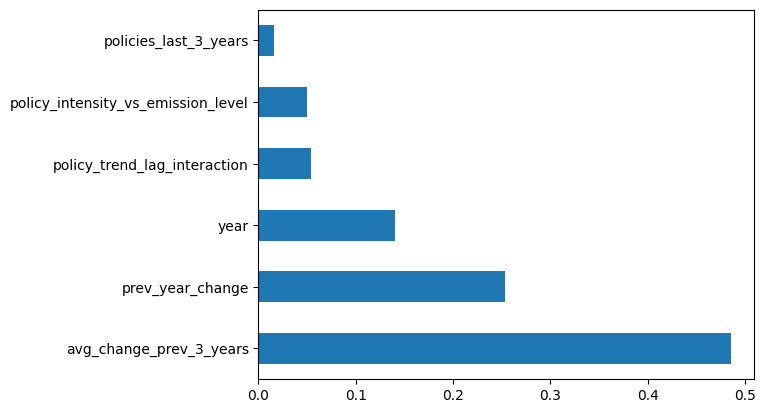

In [39]:
train_and_test_model(emissions_change_df, target, features, income_subset=['Low income'])


Train shape: (2693, 9)
Test shape: (215, 9)
train / test split: 0.7605196272239481 / 0.06071731149392827
MAE: 0.04189880953687105
R²: -0.6389140133069366


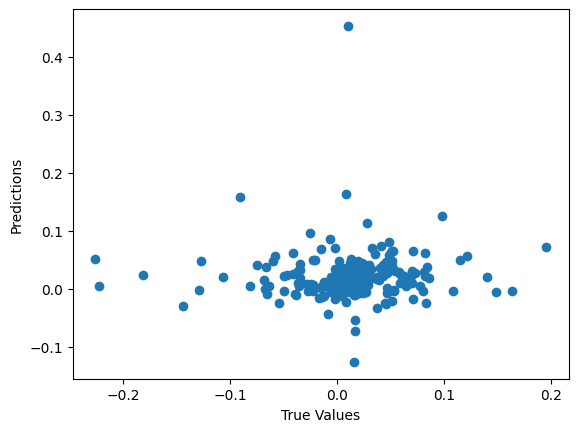

avg_change_prev_3_years               0.485517
prev_year_change                      0.253822
year                                  0.140575
policy_trend_lag_interaction          0.053566
policy_intensity_vs_emission_level    0.050388
policies_last_3_years                 0.016132
dtype: float64


RandomForestRegressor(random_state=42)

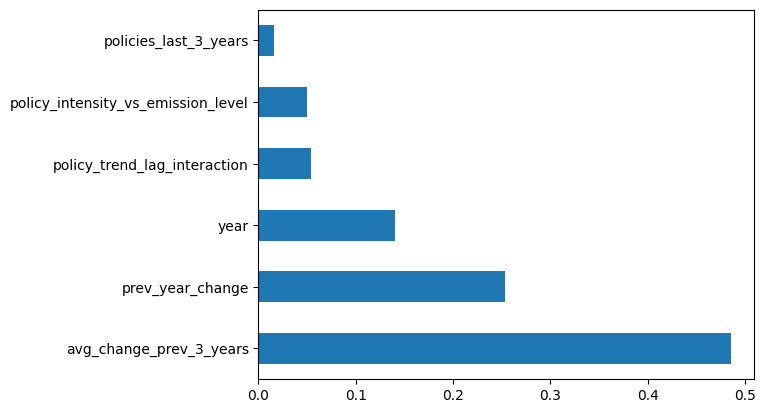

In [40]:
train_and_test_model(emissions_change_df, target, features, income_subset=['Lower middle income'])



Train shape: (2693, 9)
Test shape: (215, 9)
train / test split: 0.7605196272239481 / 0.06071731149392827
MAE: 0.06668809515888095
R²: 0.055483366132373035


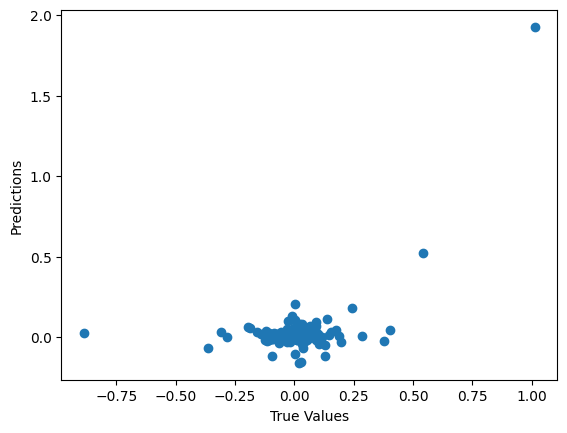

avg_change_prev_3_years               0.485517
prev_year_change                      0.253822
year                                  0.140575
policy_trend_lag_interaction          0.053566
policy_intensity_vs_emission_level    0.050388
policies_last_3_years                 0.016132
dtype: float64


RandomForestRegressor(random_state=42)

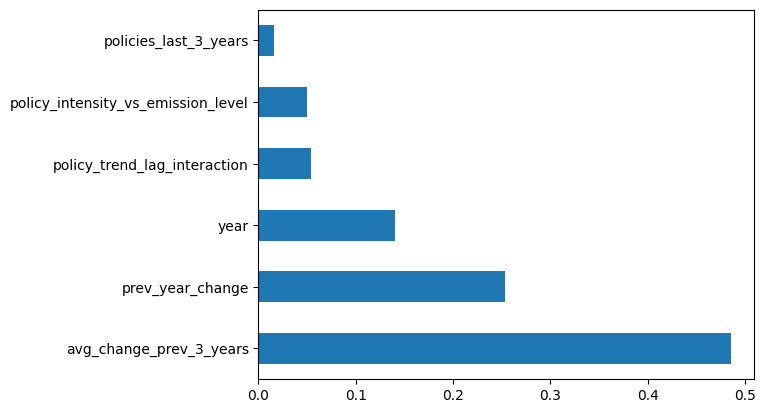

In [41]:
train_and_test_model(emissions_change_df, target, features, income_subset=['Upper middle income'])


Train shape: (2693, 9)
Test shape: (310, 9)
train / test split: 0.7605196272239481 / 0.0875458909912454


MAE: 0.07177069156700168
R²: -0.0025474337980242456


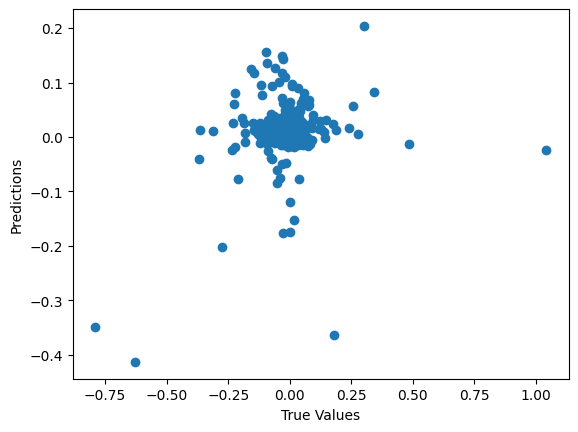

avg_change_prev_3_years               0.485517
prev_year_change                      0.253822
year                                  0.140575
policy_trend_lag_interaction          0.053566
policy_intensity_vs_emission_level    0.050388
policies_last_3_years                 0.016132
dtype: float64


RandomForestRegressor(random_state=42)

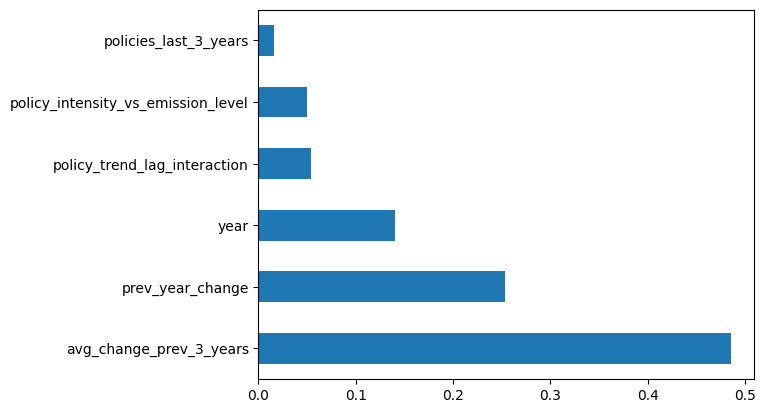

In [42]:
train_and_test_model(emissions_change_df, target, features, income_subset=['High income'])